# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [ ]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [ ]:
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
print(df_reviews.info())
print(df_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [6]:
df_clean = df_reviews[['review', 'pos', 'ds_part']]

In [7]:
print(df_clean.info())
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   review   47331 non-null  object
 1   pos      47331 non-null  int64 
 2   ds_part  47331 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None
                                              review  pos ds_part
0  The pakage implies that Warren Beatty and Gold...    0   train
1  How the hell did they get this made?! Presenti...    0   train
2  There is no real story the film seems more lik...    0    test
3  Um .... a serious film about troubled teens in...    1    test
4  I'm totally agree with GarryJohal from Singapo...    1    test


## EDA

Let's check the number of movies and reviews over years.

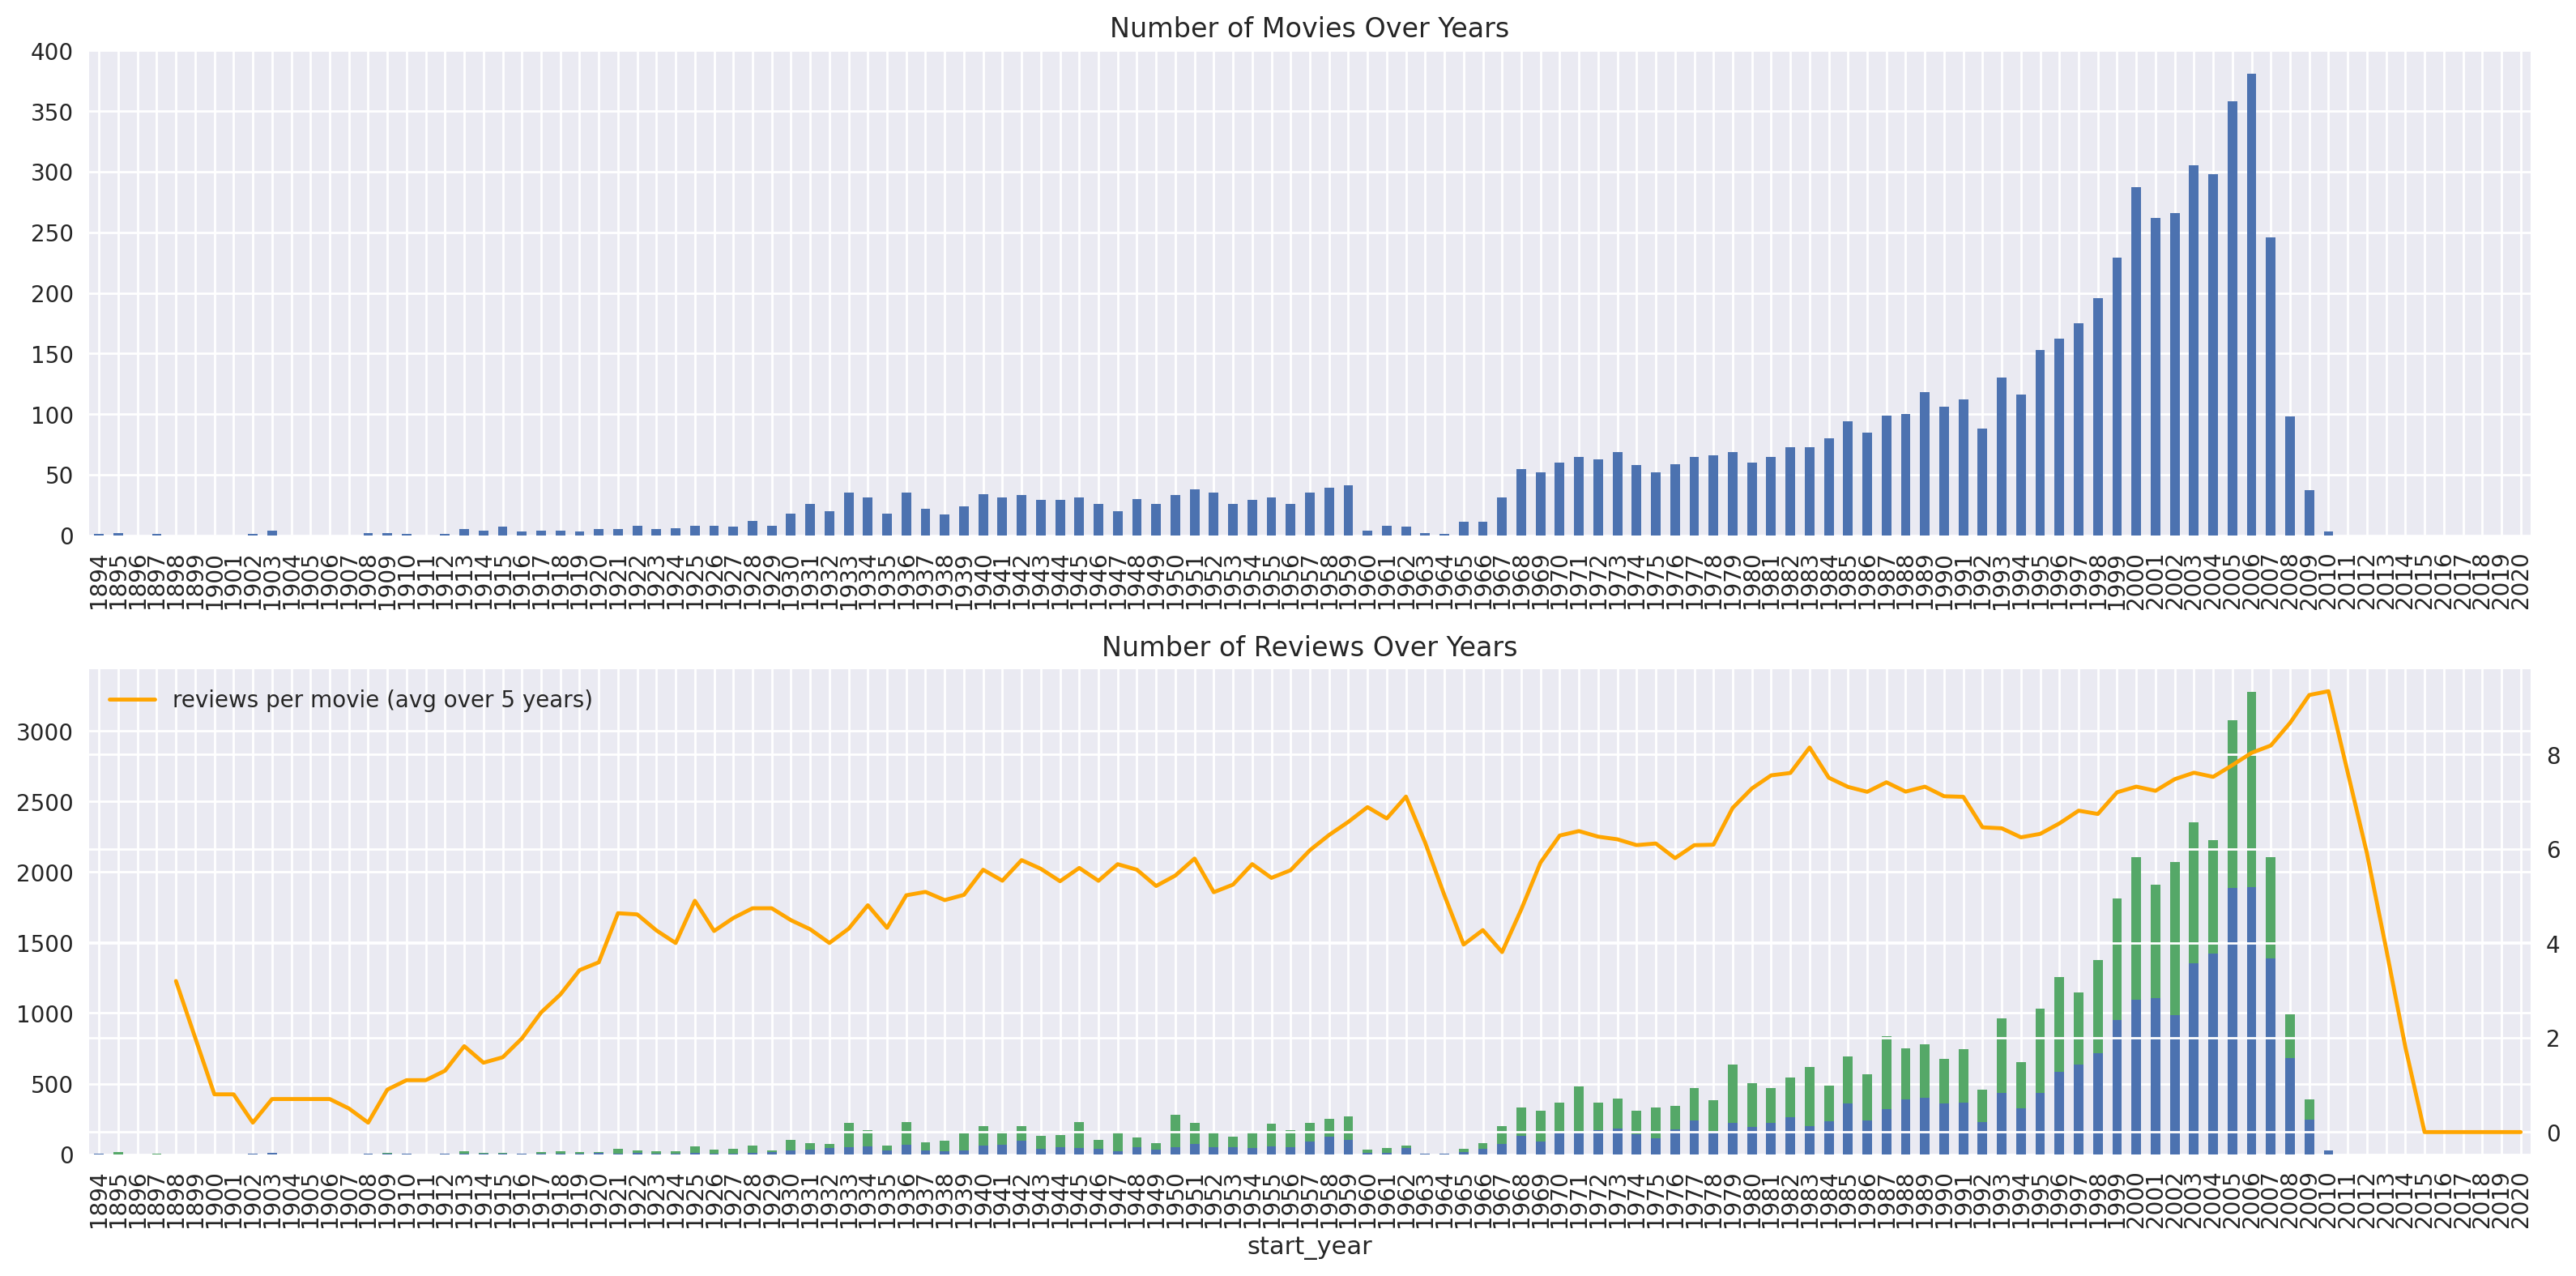

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index = np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind = 'bar', ax = ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index = np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind = 'bar', stacked = True, label = '#reviews (neg, pos)', ax = ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index = np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop = True).rolling(5).mean().plot(color = 'orange', label = 'reviews per movie (avg over 5 years)', ax = axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

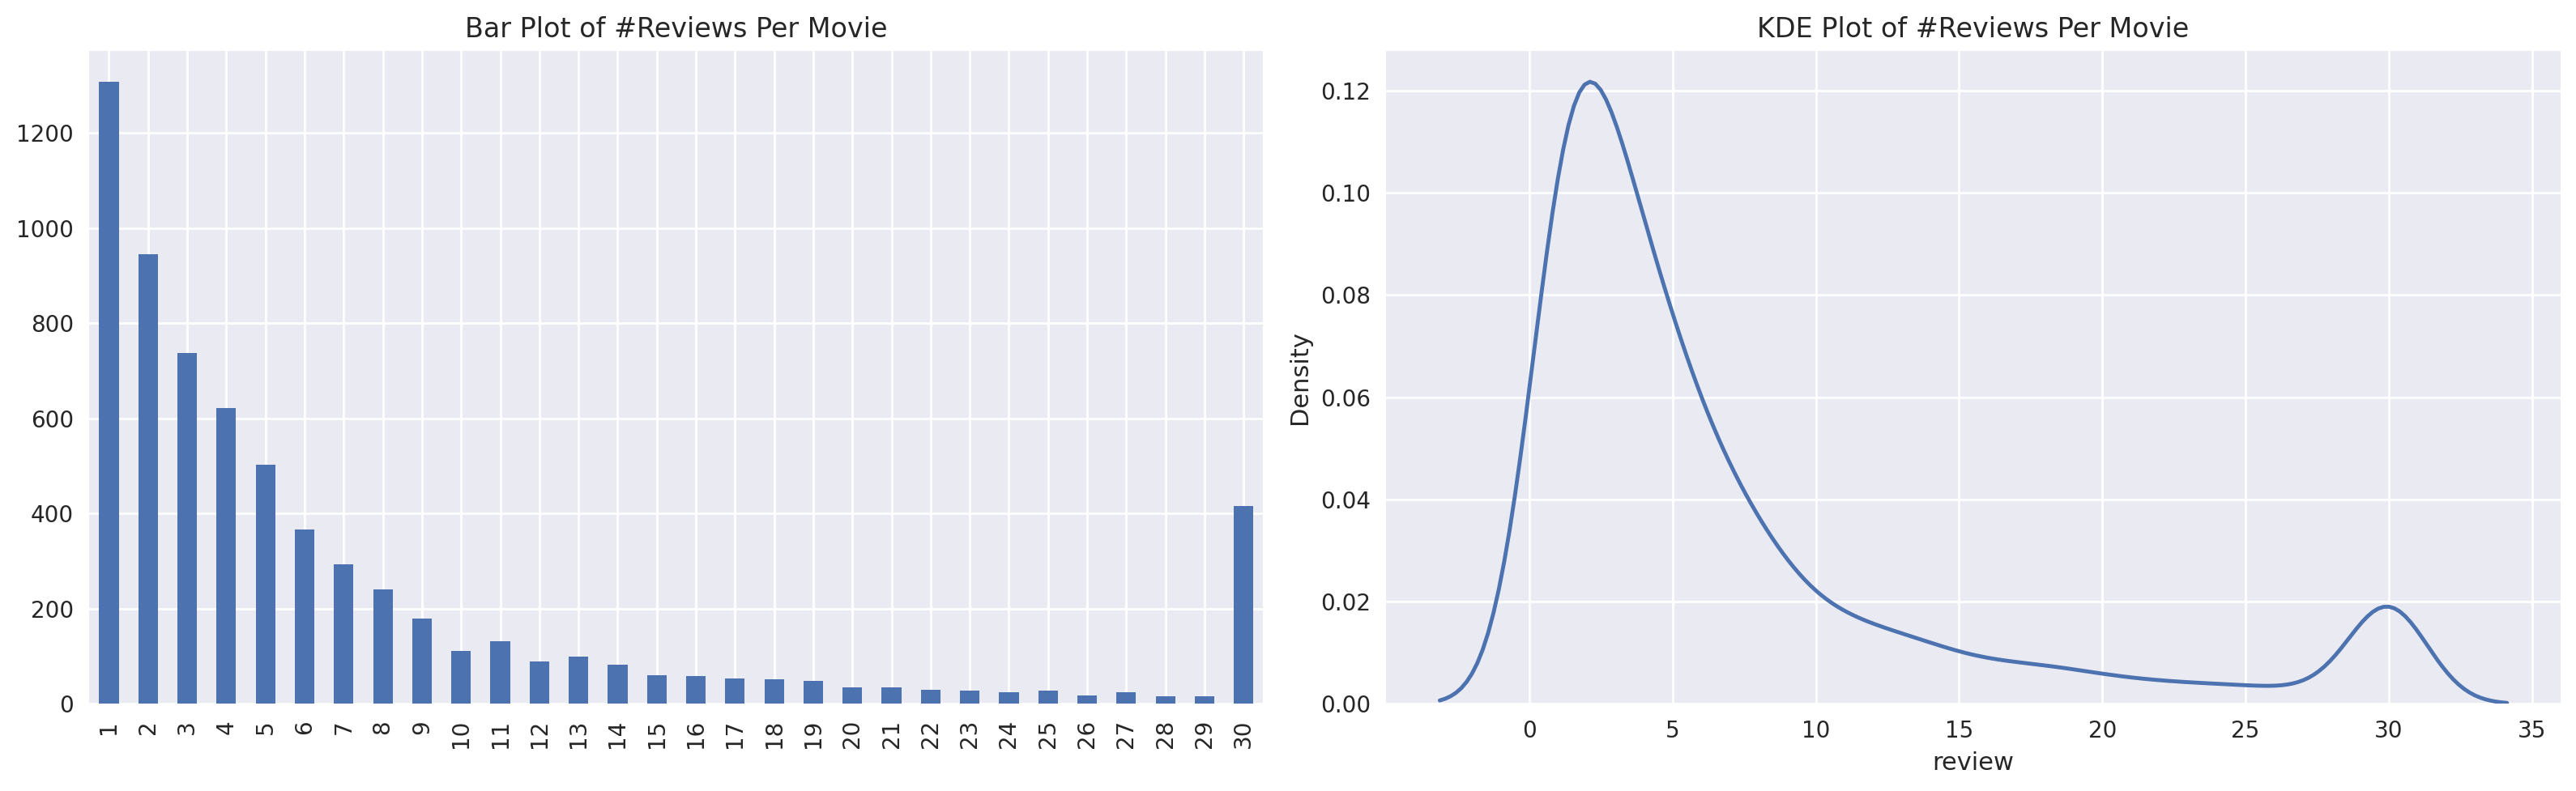

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax = ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [10]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

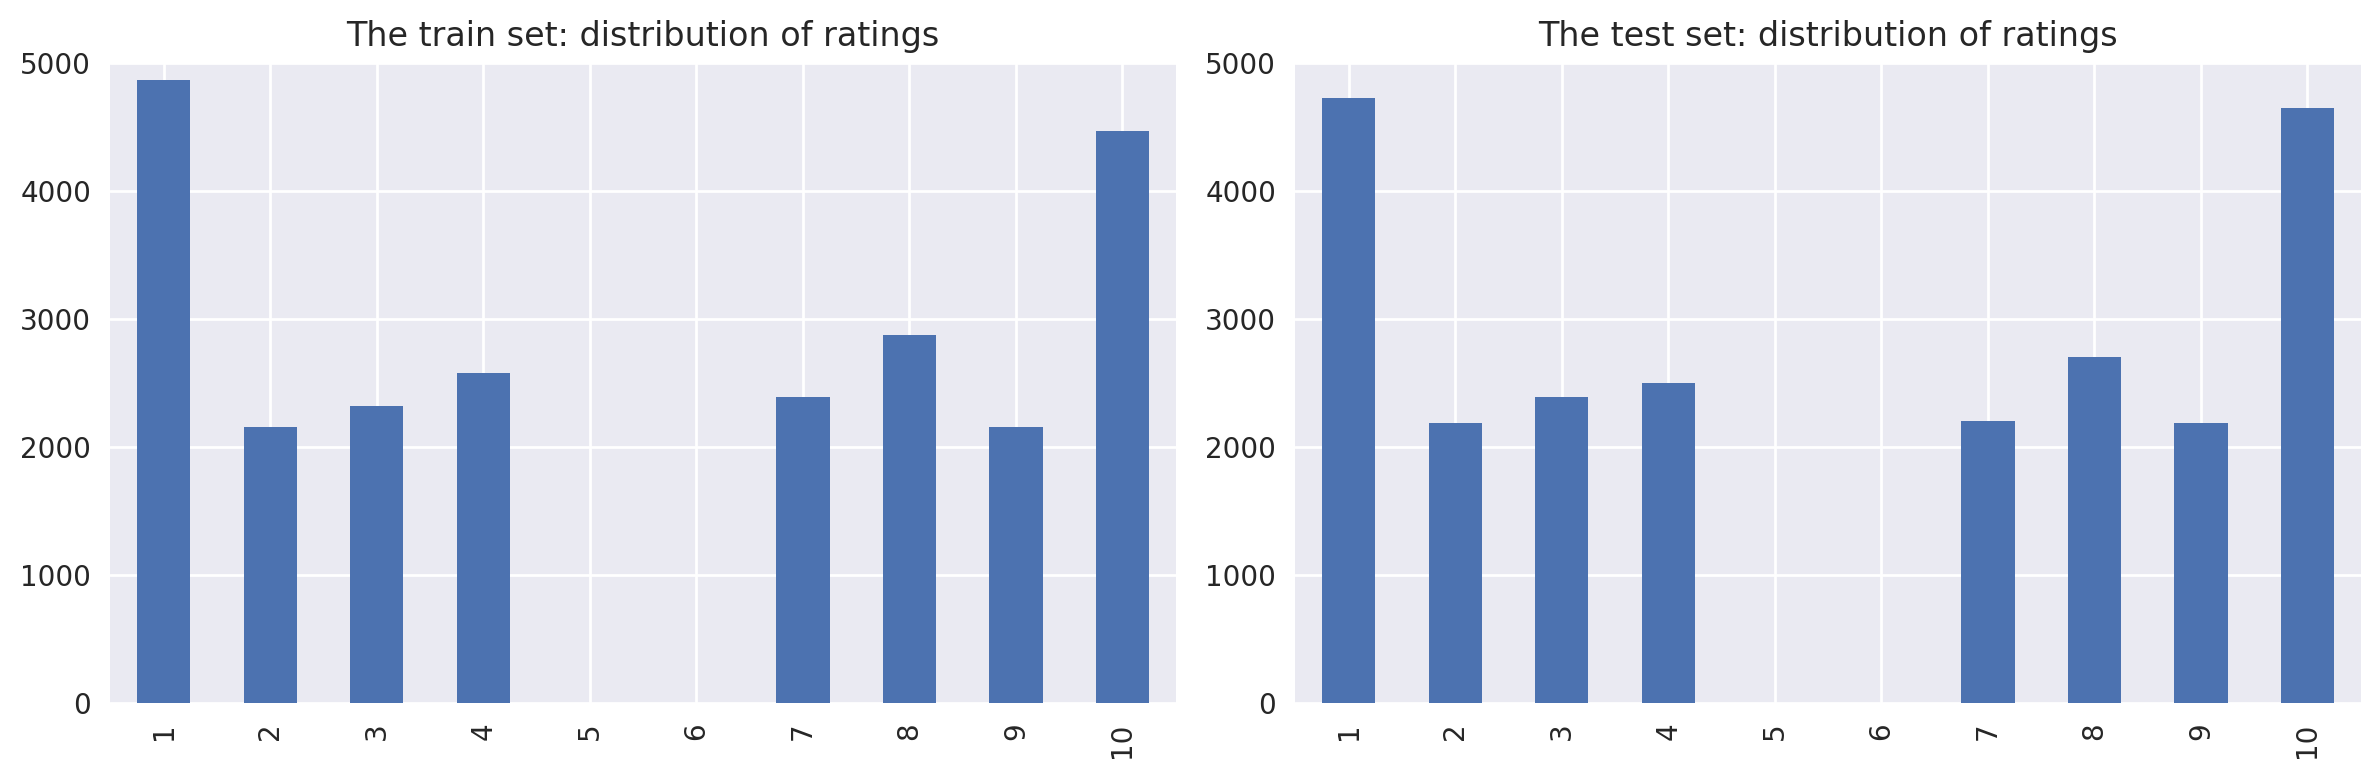

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax = ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index = np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax = ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


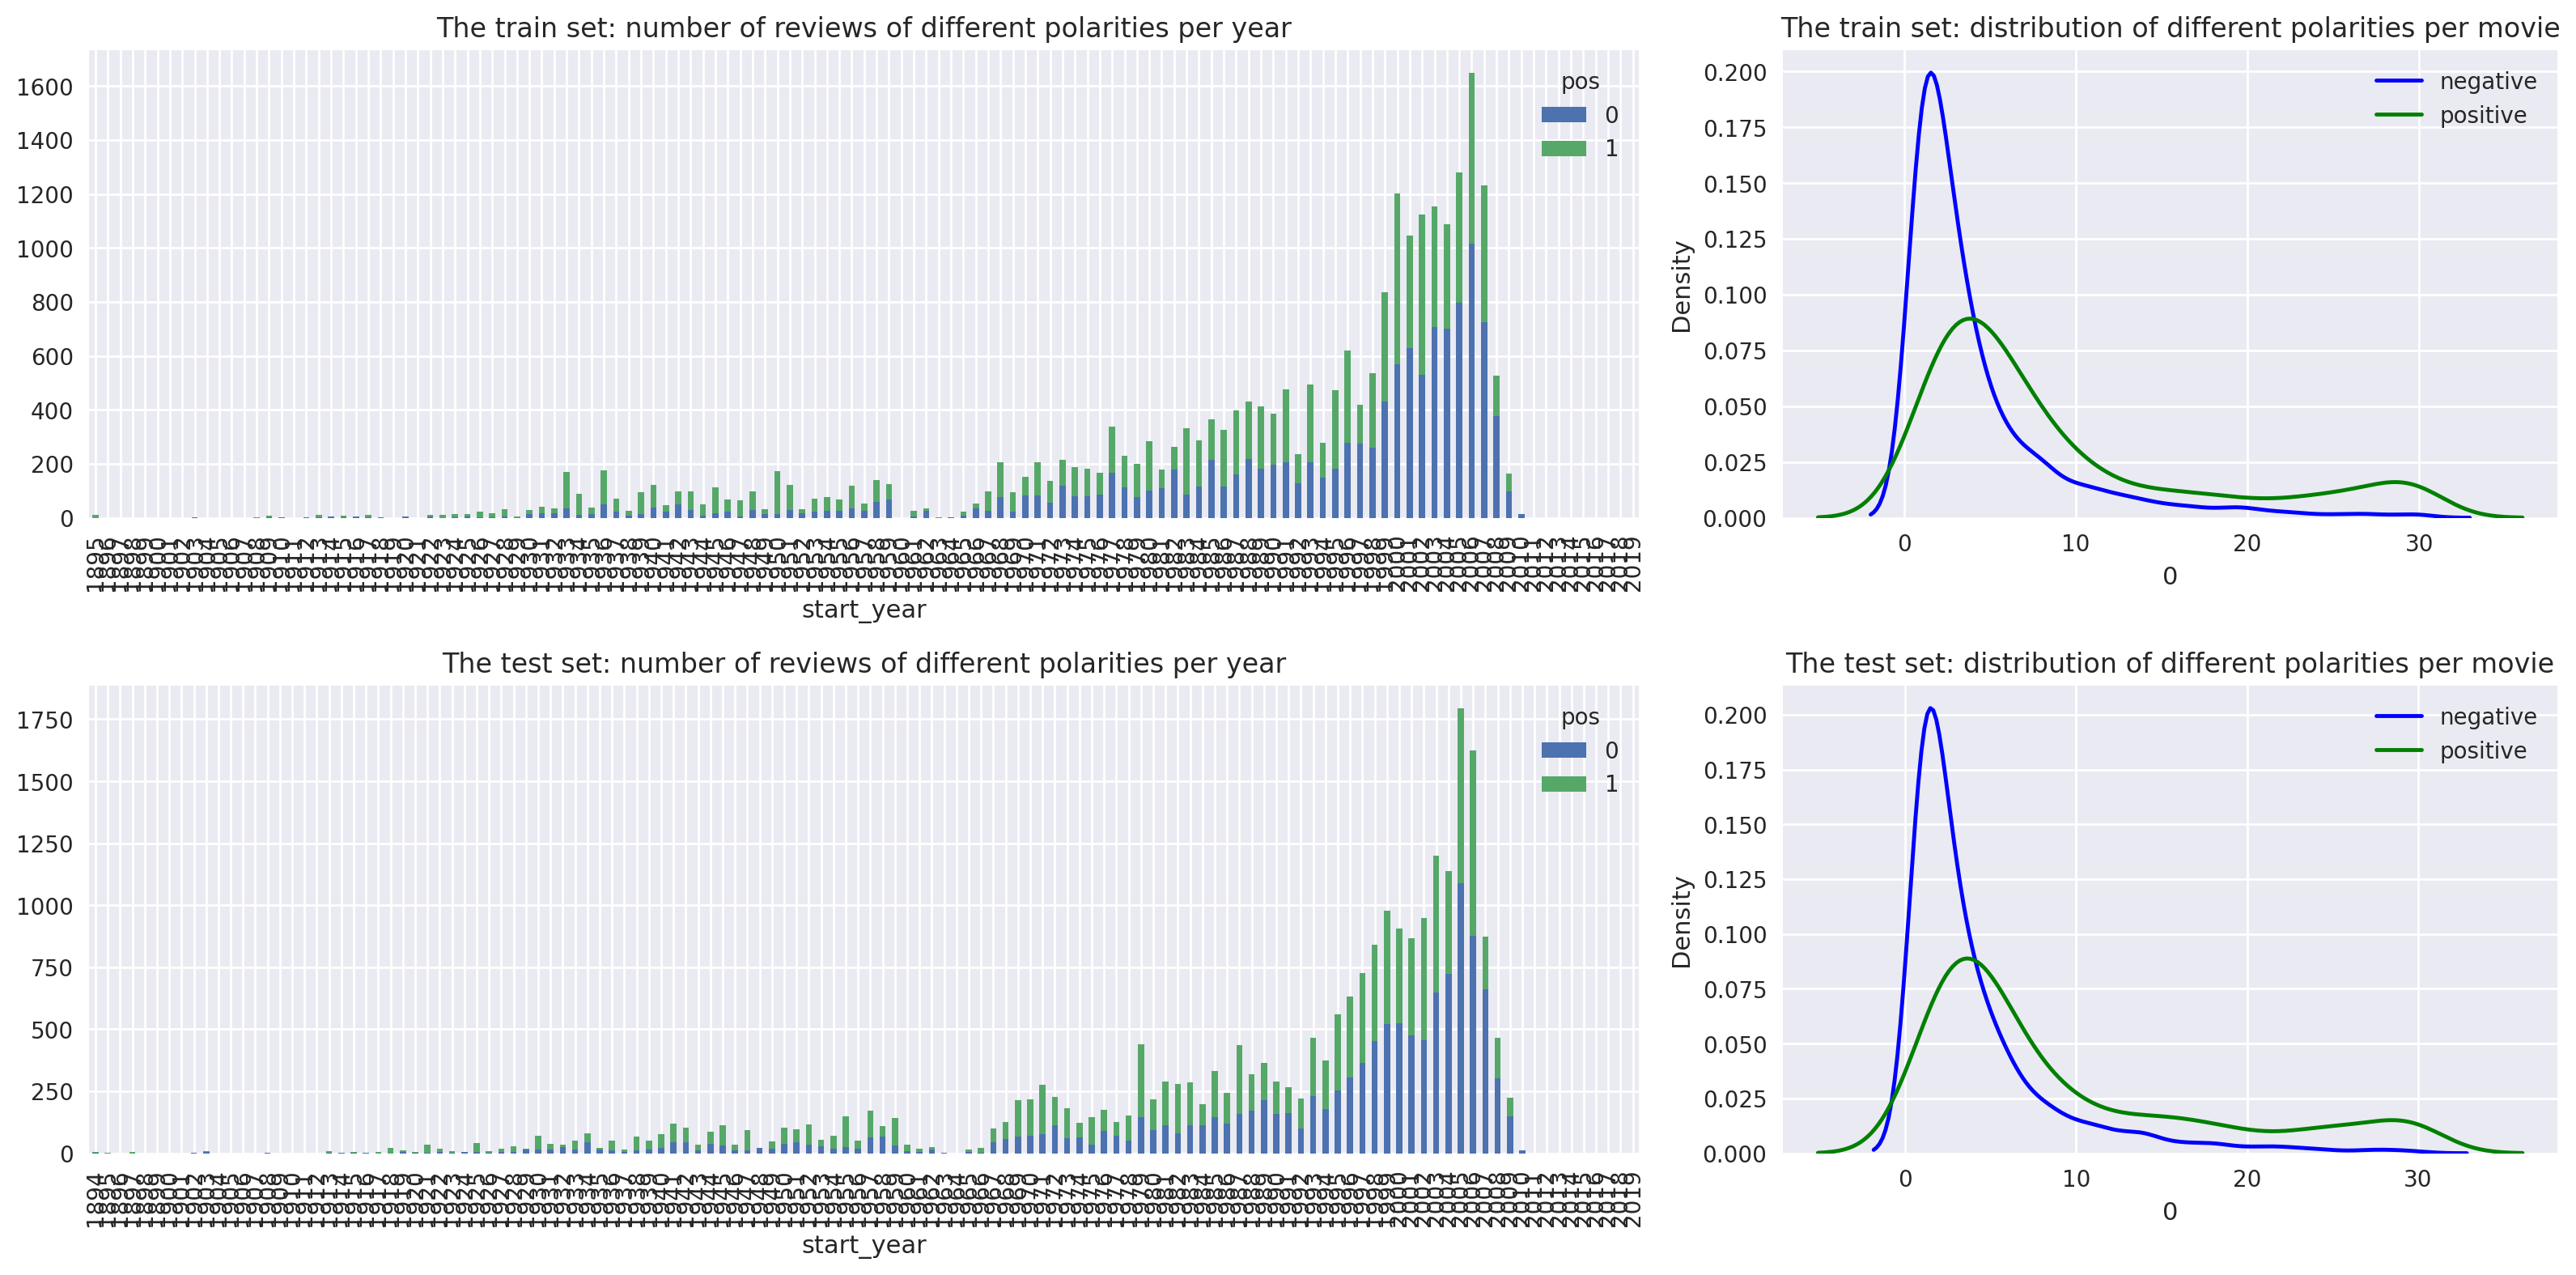

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index = np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind = 'bar', stacked = True, ax = ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color = 'blue', label = 'negative', kernel = 'epa', ax = ax)
sns.kdeplot(dft[1], color = 'green', label = 'positive', kernel = 'epa', ax = ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index = np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind = 'bar', stacked = True, ax = ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color = 'blue', label = 'negative', kernel = 'epa', ax = ax)
sns.kdeplot(dft[1], color = 'green', label = 'positive', kernel = 'epa', ax = ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

An examination of the first graph indicates that the number of reviews per movie has generally increased over time, followed by a noticeable decline in the most recent years. The distribution of positive and negative reviews appears relatively balanced overall. However, the KDE plots reveal that the data is right-skewed, indicating that most movies receive a relatively low number of reviews, with a smaller subset receiving substantially more. This skewness suggests that the mean number of reviews per movie is greater than the median, reflecting the influence of high-review outliers.

Additionally, the distributions of the training and test sets show consistent patterns, with higher and lower ratings occurring more frequently than mid-range ratings. A similar trend is observed in the density plots for positive and negative reviews, where both subsets closely mirror one another. Overall, while the data exhibits right skewness, it remains reasonably balanced, and the training and test sets demonstrate comparable distributional characteristics.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [ ]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color = color, label = f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color = marker_color, marker='X', markersize = 7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color = color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color = marker_color, marker = 'X', markersize = 7)
        ax.plot([0, 1], [0, 1], color = 'grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label = f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color = marker_color, marker = 'X', markersize = 7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [14]:
df_reviews['review_norm'] = df_reviews['review'].str.lower()
df_reviews['review_norm'] = df_reviews['review_norm'].str.replace(r'[^a-z\s]', ' ', regex = True)
df_reviews['review_norm'] = df_reviews['review_norm'].str.replace(r'\s+', ' ', regex = True).str.strip()

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [15]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [16]:
from sklearn.dummy import DummyClassifier

In [17]:
model_0 = DummyClassifier(strategy='stratified', random_state = 17)

In [18]:
train_features_0 = np.zeros((len(train_target), 1))
test_features_0 = np.zeros((len(test_target), 1))

          train  test
Accuracy    0.5   0.5
F1          0.5   0.5
APS         0.5   0.5
ROC AUC     0.5   0.5


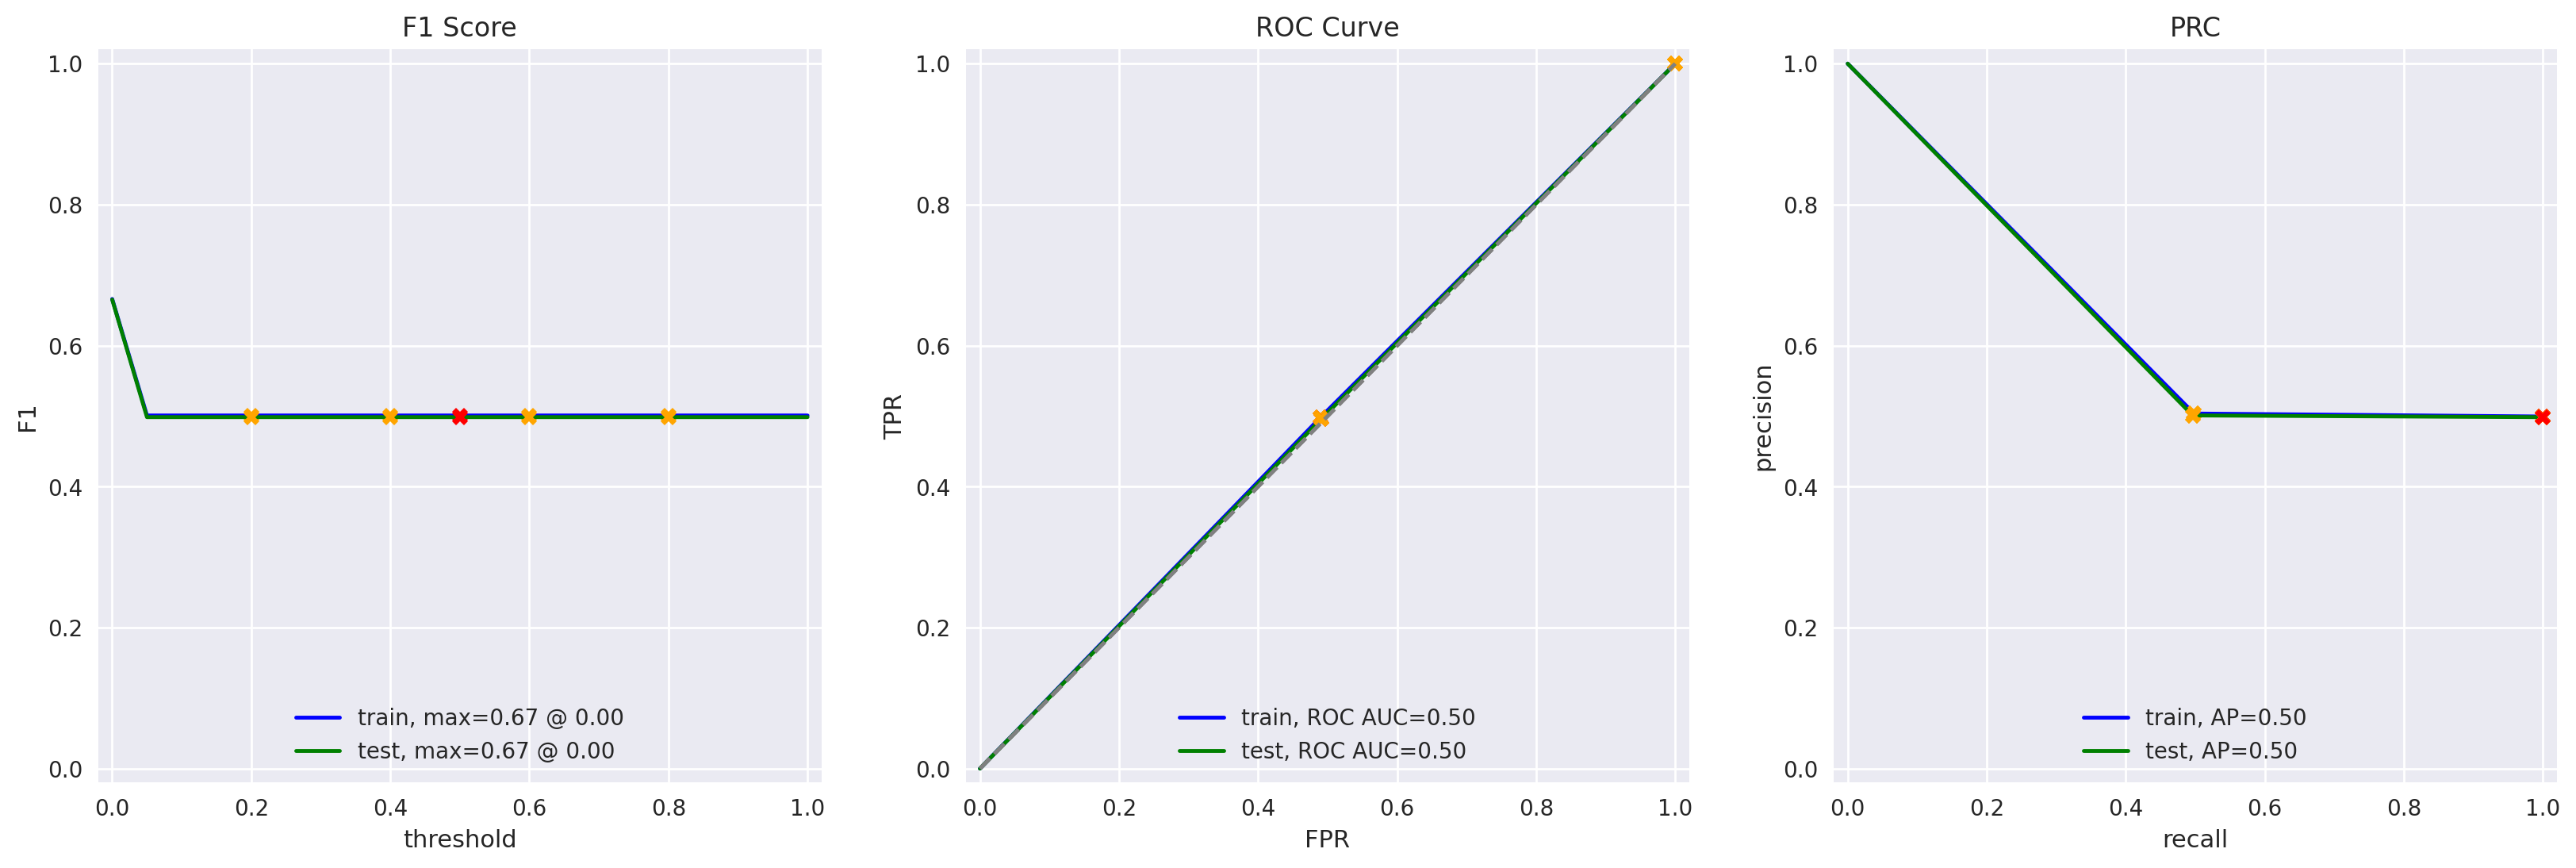

In [19]:
model_0.fit(train_features_0, train_target)
evaluate_model(model_0, train_features_0, train_target, test_features_0, test_target)

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [ ]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords

In [22]:
tfidf_vectorizer_1 = TfidfVectorizer(stop_words = 'english',
                                     ngram_range = (1, 3), max_features = 5000)
model_1 = LogisticRegression()

In [23]:
train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

model_1.fit(train_features_1, train_target)

LogisticRegression()

          train  test
Accuracy   0.92  0.88
F1         0.92  0.88
APS        0.97  0.95
ROC AUC    0.97  0.95


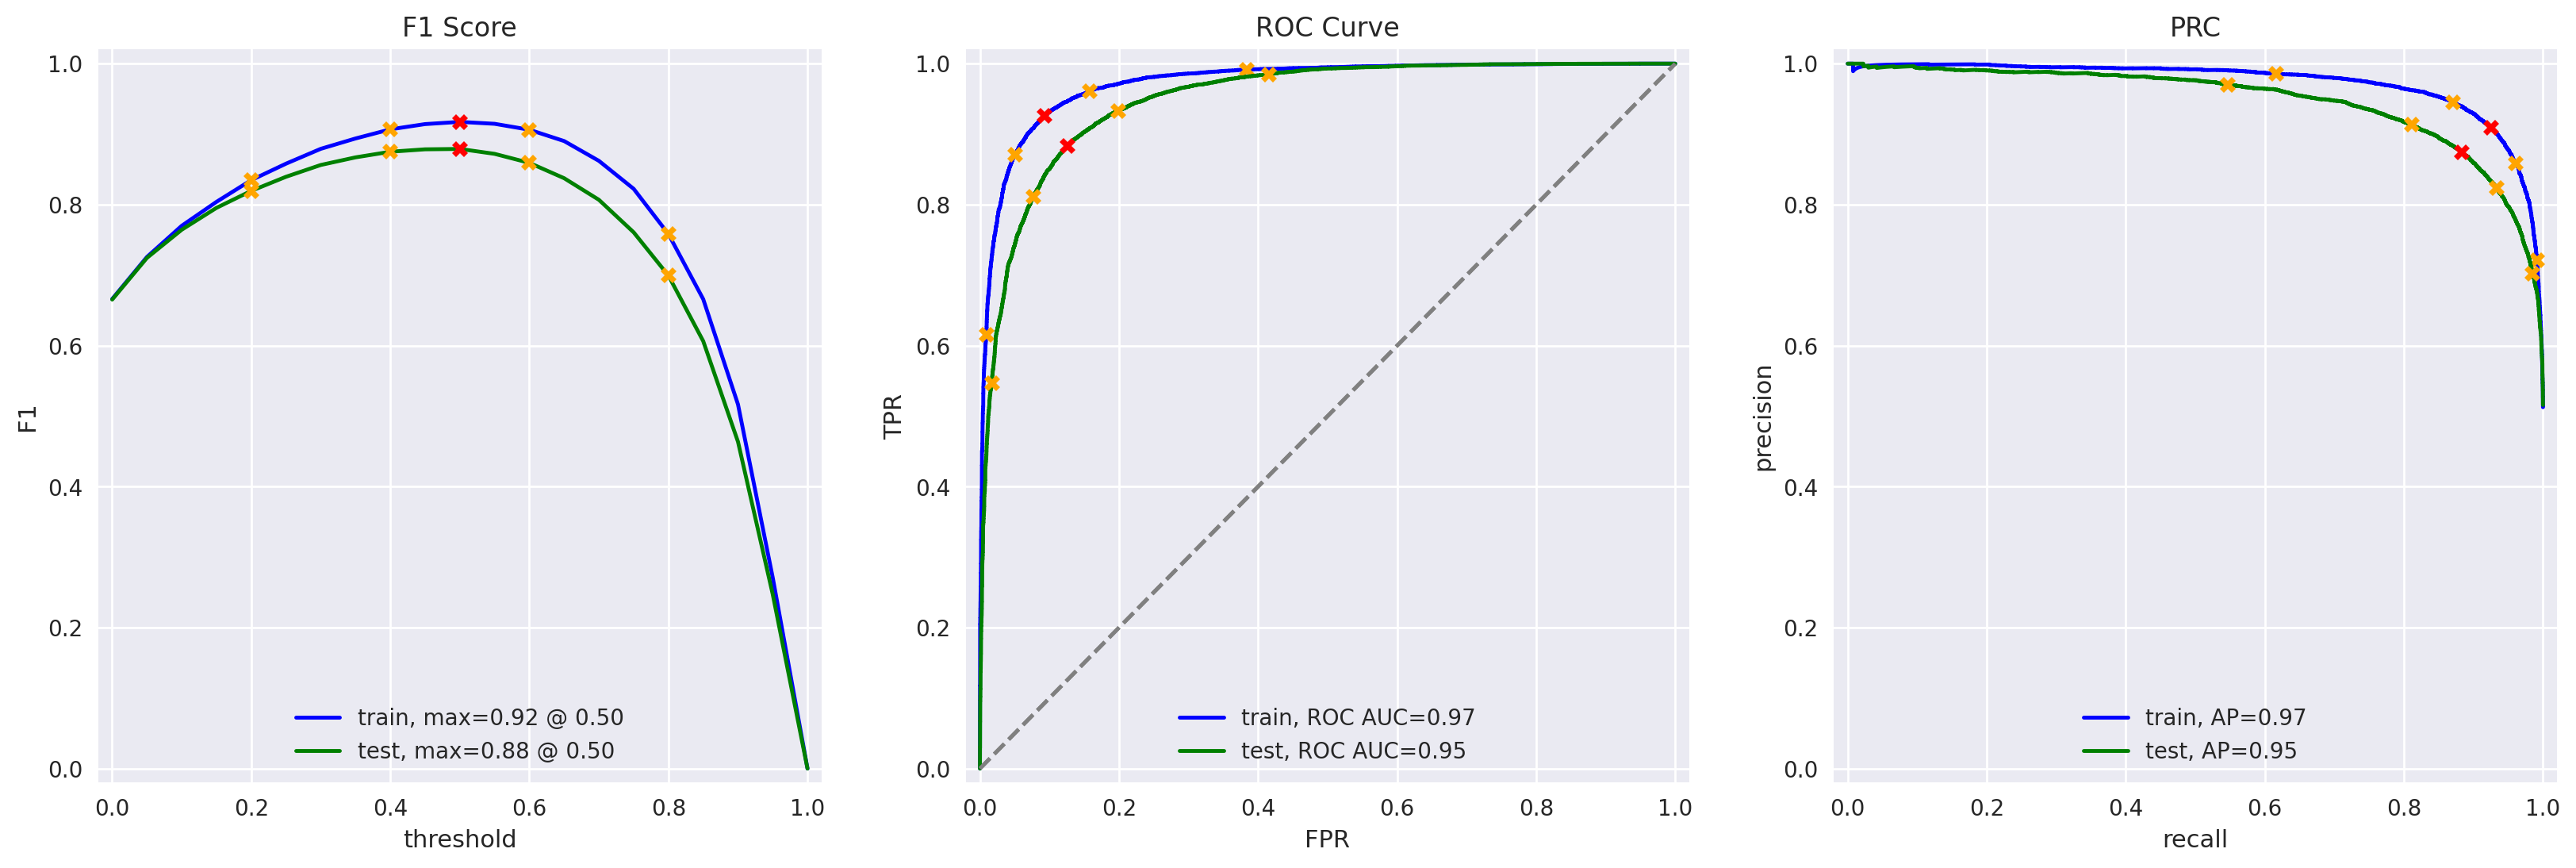

In [24]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Model 3 - spaCy, TF-IDF and LR

In [29]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [30]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

def process_in_batches(texts, batch_size = 1000):
    processed_texts = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts.iloc[i:i + batch_size]
        batch_processed = batch.apply(text_preprocessing_3)
        processed_texts.extend(batch_processed.tolist())
    return processed_texts

In [31]:
print("Processing training data in batches...")
train_texts_processed = process_in_batches(df_reviews_train['review_norm'], batch_size = 1000)

print("Processing test data in batches...")
test_texts_processed = process_in_batches(df_reviews_test['review_norm'], batch_size = 1000)

tfidf_vectorizer_3 = TfidfVectorizer(stop_words = 
                                     'english', ngram_range = (1, 2), max_features = 5000)
train_features_3 = tfidf_vectorizer_3.fit_transform(train_texts_processed)
test_features_3 = tfidf_vectorizer_3.transform(test_texts_processed)

Processing training data in batches...


  0%|          | 0/24 [00:00<?, ?it/s]

Processing test data in batches...


  0%|          | 0/24 [00:00<?, ?it/s]

In [32]:
model_3 = LogisticRegression()
model_3.fit(train_features_3, train_target)

LogisticRegression()

          train  test
Accuracy   0.91  0.88
F1         0.91  0.88
APS        0.97  0.94
ROC AUC    0.97  0.95


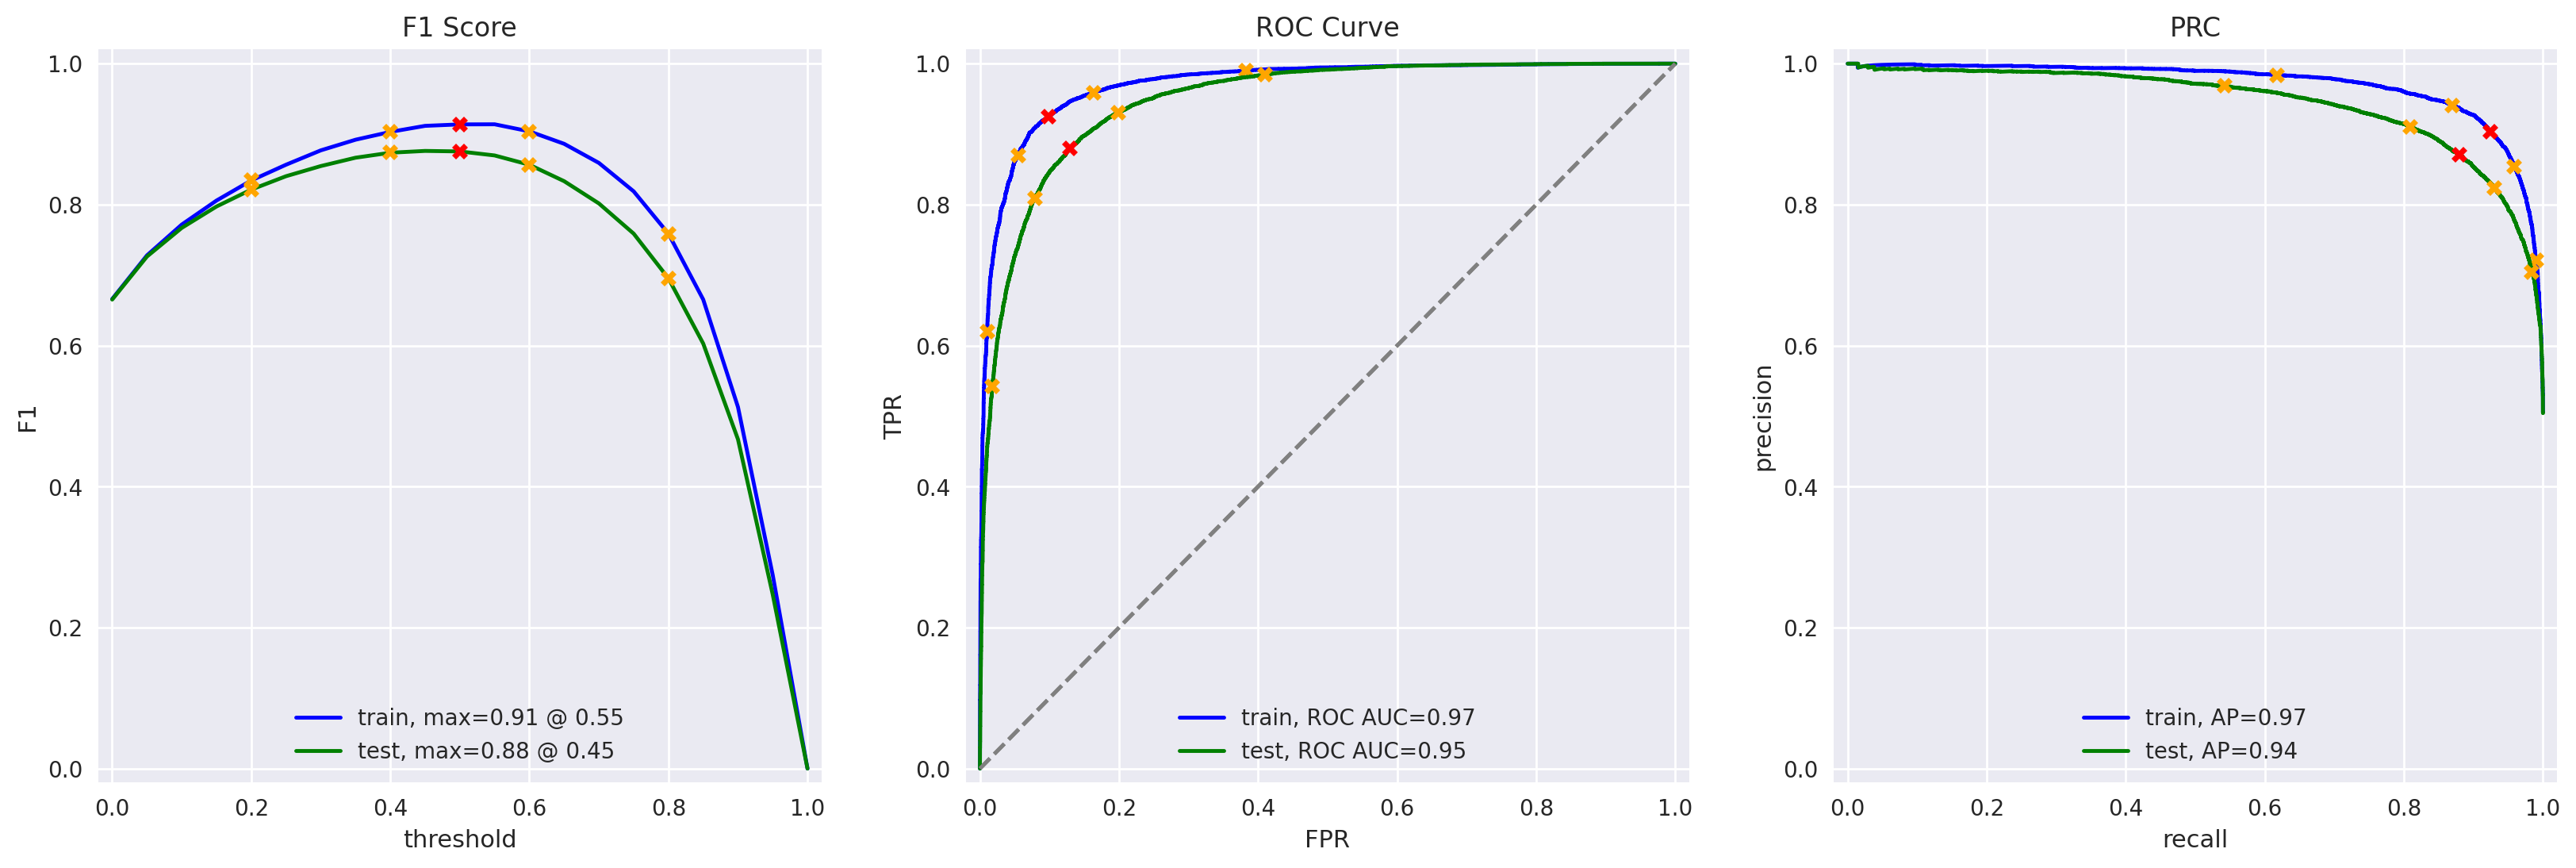

In [28]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [17]:
from lightgbm import LGBMClassifier

In [18]:
tfidf_vectorizer_4 = TfidfVectorizer(stop_words = 'english',
                                     ngram_range = (1, 2), max_features = 5000)
train_features_4 = tfidf_vectorizer_4.fit_transform(df_reviews_train['review_norm']).toarray()  
test_features_4 = tfidf_vectorizer_4.transform(df_reviews_test['review_norm']).toarray() 

In [19]:
model_4 = LGBMClassifier(
    objective = 'binary', metric='binary_logloss', boosting_type = 'gbdt', num_leaves = 31,
    learning_rate = 0.1, feature_fraction = 0.9, random_state = 17)
model_4.fit(train_features_4, train_target)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9


LGBMClassifier(feature_fraction=0.9, metric='binary_logloss',
               objective='binary', random_state=17)

          train  test
Accuracy   0.91  0.86
F1         0.91  0.86
APS        0.97  0.93
ROC AUC    0.97  0.94
Unique predictions: [0 1]
Prediction counts: [11548 11987]


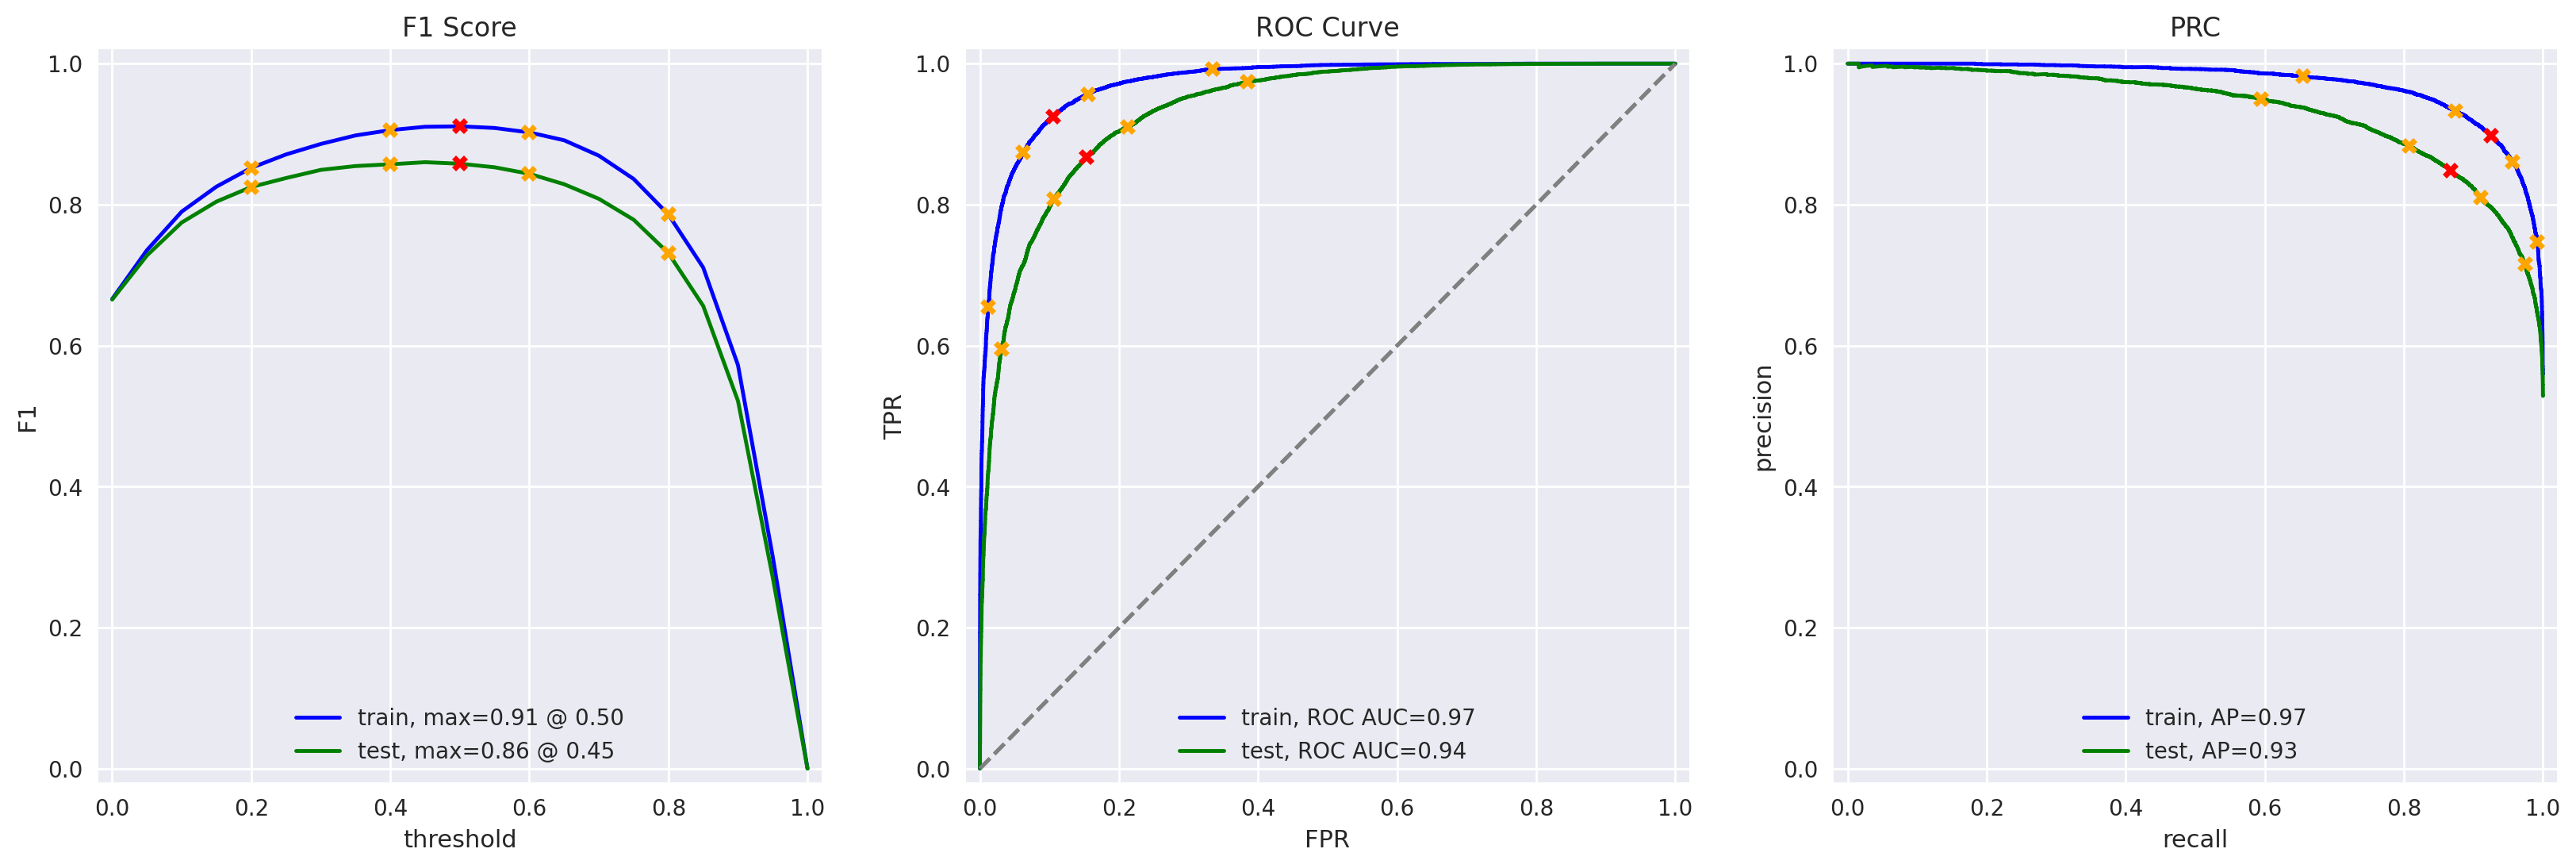

In [20]:
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)
predictions = model_4.predict(test_features_4)
print("Unique predictions:", np.unique(predictions))
print("Prediction counts:", np.bincount(predictions))

## My Reviews

In [ ]:

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])


my_reviews['review_norm'] = my_reviews['review'].str.lower()
my_reviews['review_norm'] = my_reviews['review_norm'].str.replace(r'[^a-z\s]', ' ', regex = True)
my_reviews['review_norm'] = my_reviews['review_norm'].str.replace(r'\s+', ' ', regex = True).str.strip()

### Model 1

In [27]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.19:  i did not simply like it not my kind of movie
0.07:  well i was bored and felt asleep in the middle of the movie
0.41:  i was really fascinated with the movie
0.16:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.18:  i didn t expect the reboot to be so good writers really cared about the source material
0.39:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.94:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 3

In [33]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.28:  i did not simply like it not my kind of movie
0.10:  well i was bored and felt asleep in the middle of the movie
0.44:  i was really fascinated with the movie
0.14:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.13:  i didn t expect the reboot to be so good writers really cared about the source material
0.32:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.05:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.95:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 4

In [22]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.56:  i did not simply like it not my kind of movie
0.41:  well i was bored and felt asleep in the middle of the movie
0.67:  i was really fascinated with the movie
0.45:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.60:  i didn t expect the reboot to be so good writers really cared about the source material
0.66:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.23:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.75:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


## Conclusions

After training multiple models and experimenting with different parameter configurations—including variations in max features, n-grams, and preprocessing techniques—all models successfully exceeded the established F1 score threshold of 0.85. Model 1 (NLTK + TF-IDF + Logistic Regression) achieved an F1 score of 0.88, and Model 3 (spaCy + TF-IDF + Logistic Regression with batch processing) also achieved an F1 score of 0.88. These results indicate strong overall classification performance, demonstrating an effective balance between precision and recall. In practical terms, an F1 score of 0.88 reflects the models’ ability to accurately identify relevant instances while minimizing both false positives and false negatives. Model 4 (spaCy + TF-IDF + LGBMClassifier) achieved an F1 score of 0.86. While slightly lower than Models 1 and 3, this score still represents solid and reliable predictive performance, comfortably surpassing the benchmark of 0.85. An F1 score of 0.86 indicates that the model maintains a strong balance between correctly identifying positive cases and limiting classification errors. Overall, these results demonstrate that all evaluated models meet and exceed the desired performance threshold, indicating robust classification capability and effective generalization. 